<a href="https://colab.research.google.com/github/fioremartiro/Machine-Learning/blob/main/Supervised%20Learning/Classification%20Examples/2.%20linear_discriminant_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 0. Import dependencies

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

### 1. Load the dataset

In [18]:
# 1. Cargar datos reales y preparar
data = load_breast_cancer()
X, y = data.data[:, :2], data.target  # We use the first two variables to graph
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (569, 2)
Shape of y: (569,)


### 2. Split into Train and Test sets properly

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. Scale the data

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Train the Linear Discriminant Analysis (LDA) classifier

In [16]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

LinearDiscriminantAnalysis()

### 5. Visualization


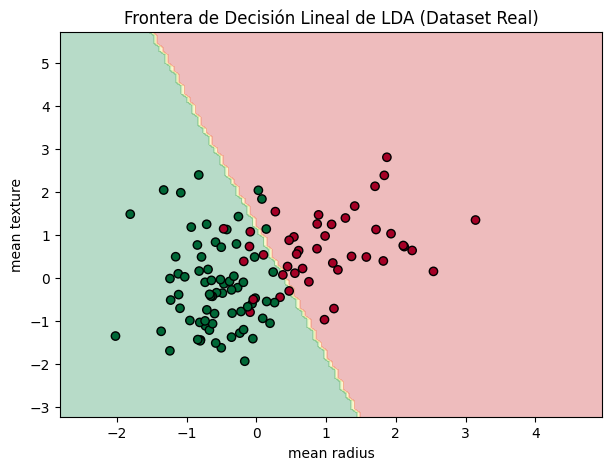

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

# Este comando de sklearn dibuja el fondo (la frontera de decisión) automáticamente
DecisionBoundaryDisplay.from_estimator(
    lda, X_train_scaled, response_method="predict",
    cmap="RdYlGn", alpha=0.3, ax=ax
)

# Dibujar los puntos reales encima
scatter = ax.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, cmap="RdYlGn", edgecolors="k")
ax.set_title("Frontera de Decisión Lineal de LDA (Dataset Real)")
ax.set_xlabel(data.feature_names[0])
ax.set_ylabel(data.feature_names[1])

plt.show()